In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [3]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figure13_FreshwaterTransport_SWG')

s_vs = np.load('ANHA4-EJM010-S_2004-2017_vosaline_SWG.npz')['vosaline']
s_vd = np.load('ANHA4-EJM012-S_2004-2017_vosaline_SWG.npz')['vosaline']

u_vs = np.load('ANHA4-EJM010-S_2004-2017_vozocrtx_SWG.npz')['vozocrtx']
u_vd = np.load('ANHA4-EJM012-S_2004-2017_vozocrtx_SWG.npz')['vozocrtx']

In [4]:
mesh = xr.open_dataset('/Users/gawasi001/Documents/Paper_msc/Data_uofm/ANHA4_mesh_zgr.nc')

lat_swg = np.arange(367, 380)
lon_swg = 225

e3t = mesh['e3t_0'].values[0, :50]

e2u = mesh['e2u'].values[0, lat_swg, lon_swg]

area = e3t[:, None] * e2u[None, :]

In [10]:
sref = 34.8

fwc_vs = (sref - s_vs) / sref
fwc_vd = (sref - s_vd) / sref

west_vs = (u_vs < 0) & (fwc_vs > 0)
west_vd = (u_vd < 0) & (fwc_vd > 0)

transport_vs = np.where(west_vs, u_vs * fwc_vs, np.nan)
transport_vd = np.where(west_vd, u_vd * fwc_vd, np.nan)

fwt_vs = np.nansum(transport_vs * area[None, :, :], axis=(1, 2)) / 1e3
fwt_vd = np.nansum(transport_vd * area[None, :, :], axis=(1, 2)) / 1e3

fwt_difference = (fwt_vd) - (fwt_vs)

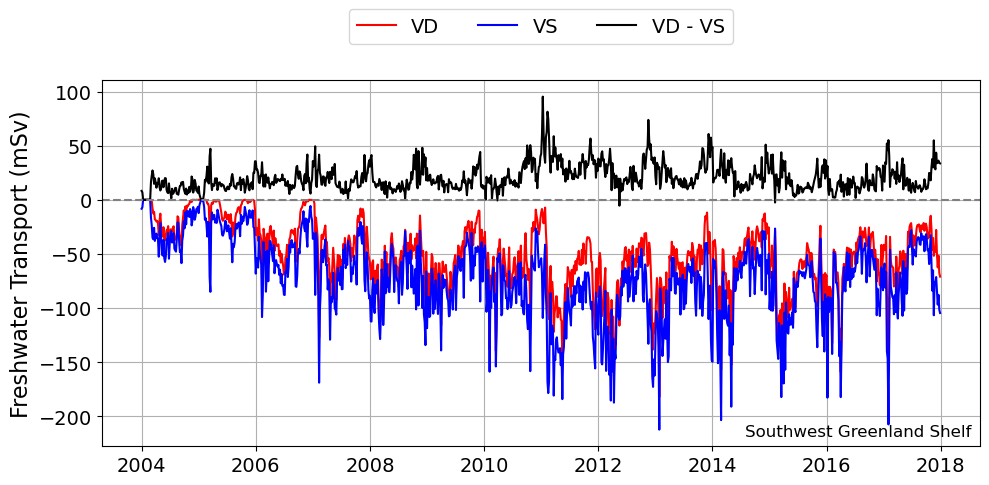

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=True)

ax.plot(fwt_vd, color='red')
ax.plot(fwt_vs, color='blue')
ax.plot(fwt_difference , color='black')
ax.axhline(y=0, color='grey', linestyle='--')
ax.grid(True)

ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel('Freshwater Transport (mSv)', fontsize = 16)

ax.legend(['VD', 'VS', 'VD - VS'], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.22), ncol=3)

ax.text(0.99, 0.02, 'Southwest Greenland Shelf', transform=ax.transAxes, ha='right', va='bottom', fontsize=12)

year_ticks = np.arange(0, 1022+73, 73 * 2)
year_labels = np.arange(2004, 2019, 2)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, fontsize = 14)

plt.tight_layout()

outdir = '/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figure13_FreshwaterTransport_SWG'

plt.savefig(os.path.join(outdir, 'Freshwater_Transport_SWG.png'), dpi=300, bbox_inches='tight')

plt.show()